<a href="https://colab.research.google.com/github/Ethan2417/UCI_Real_State_mini_project/blob/main/UCI_Real_State_mini_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [29]:
#importing relevant libraries
import pandas as pd
from sklearn.linear_model import LinearRegression

In [30]:
data = pd.read_excel("/content/Real estate valuation data set.xlsx")

In [31]:
# creating the copy of the data
df = data.copy()
df.head()

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,1,2012.916667,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.916667,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583333,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500000,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833333,5.0,390.56840,5,24.97937,121.54245,43.1


In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 414 entries, 0 to 413
Data columns (total 8 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   No                                      414 non-null    int64  
 1   X1 transaction date                     414 non-null    float64
 2   X2 house age                            414 non-null    float64
 3   X3 distance to the nearest MRT station  414 non-null    float64
 4   X4 number of convenience stores         414 non-null    int64  
 5   X5 latitude                             414 non-null    float64
 6   X6 longitude                            414 non-null    float64
 7   Y house price of unit area              414 non-null    float64
dtypes: float64(6), int64(2)
memory usage: 26.0 KB


In [33]:
#checking the stats
df.describe()

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
count,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000
mean,207.500000,2013.148953,17.712560,1083.885689,4.094203,24.969030,121.533361,37.980193
std,119.655756,0.281995,11.392485,1262.109595,2.945562,0.012410,0.015347,13.606488
min,1.000000,2012.666667,0.000000,23.382840,0.000000,24.932070,121.473530,7.600000
25%,104.250000,2012.916667,9.025000,289.324800,1.000000,24.963000,121.528085,27.700000
50%,207.500000,2013.166667,16.100000,492.231300,4.000000,24.971100,121.538630,38.450000
75%,310.750000,2013.416667,28.150000,1454.279000,6.000000,24.977455,121.543305,46.600000
max,414.000000,2013.583333,43.800000,6488.021000,10.000000,25.014590,121.566270,117.500000


In [34]:
#checking the null values
df.isnull().sum()

,0
No,0
X1 transaction date,0
X2 house age,0
X3 distance to the nearest MRT station,0
X4 number of convenience stores,0
X5 latitude,0
X6 longitude,0
Y house price of unit area,0


In [35]:
#dropping the unhelpful column
df.drop("No", axis = 1, inplace=True)
df.head()

,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,2012.916667,32.0,84.87882,10,24.98298,121.54024,37.9
1,2012.916667,19.5,306.59470,9,24.98034,121.53951,42.2
2,2013.583333,13.3,561.98450,5,24.98746,121.54391,47.3
3,2013.500000,13.3,561.98450,5,24.98746,121.54391,54.8
4,2012.833333,5.0,390.56840,5,24.97937,121.54245,43.1


In [36]:
df.corr()

,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
X1 transaction date,1.000000,0.017542,0.060880,0.009544,0.035016,-0.041065,0.087529
X2 house age,0.017542,1.000000,0.025622,0.049593,0.054420,-0.048520,-0.210567
X3 distance to the nearest MRT station,0.060880,0.025622,1.000000,-0.602519,-0.591067,-0.806317,-0.673613
X4 number of convenience stores,0.009544,0.049593,-0.602519,1.000000,0.444143,0.449099,0.571005
X5 latitude,0.035016,0.054420,-0.591067,0.444143,1.000000,0.412924,0.546307
X6 longitude,-0.041065,-0.048520,-0.806317,0.449099,0.412924,1.000000,0.523287
Y house price of unit area,0.087529,-0.210567,-0.673613,0.571005,0.546307,0.523287,1.000000


In [37]:
#Define X and y
X = df.drop("Y house price of unit area", axis = 1)
y = df["Y house price of unit area"]

In [38]:
#check dimension
print("X_shape:", X.shape)
print("y_shape:", y.shape)

X_shape: (414, 6)
y_shape: (414,)


In [39]:
#performing train test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 42
)

In [40]:
model = LinearRegression()

In [41]:
model.fit(X_train, y_train)

LinearRegression()

In [42]:
y_pred = model.predict(X_test)

In [43]:
#r2
r2 = model.score(X_test, y_test)
print("r2:", r2)

r2: 0.6810781244679265


In [44]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
MAE = mean_absolute_error(y_test, y_pred)
MSE = mean_squared_error(y_test, y_pred)
RMSE = np.sqrt(MSE)

print("MAE:", MAE)
print("MSE:", MSE)
print("RMSE:", RMSE)

MAE: 5.305232952584752
MSE: 53.502252361179515
RMSE: 7.314523385783897


In [45]:
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

Intercept: -13048.143379370988
Coefficients: [ 5.44326242e+00 -2.70794297e-01 -4.75868310e-03  1.09146922e+00
  2.29049043e+02 -2.95033895e+01]


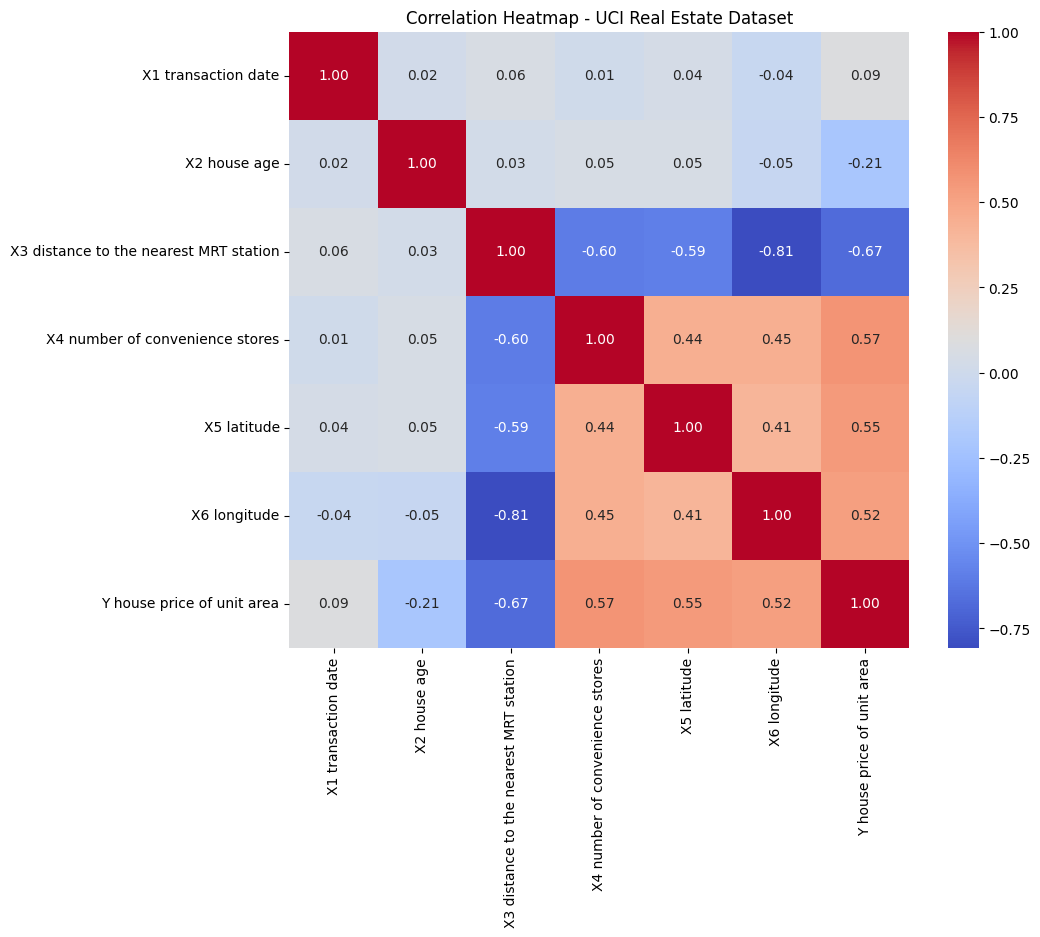

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap - UCI Real Estate Dataset")
plt.show()

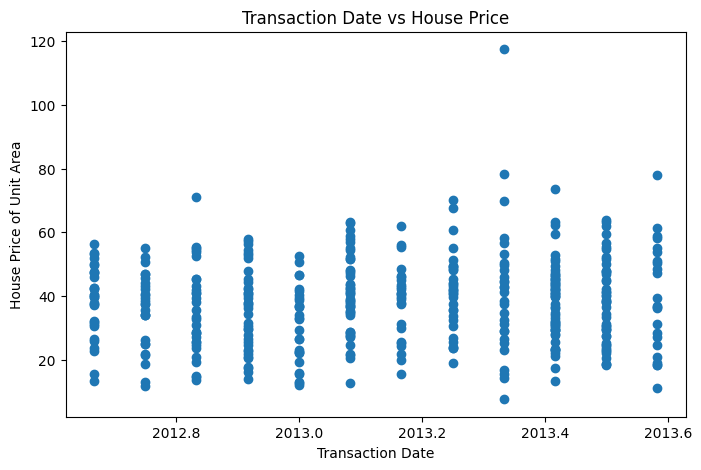

In [47]:
#Feature v/s house price scatter plot
plt.figure(figsize=(8,5))

plt.scatter(
    df["X1 transaction date"],
    df["Y house price of unit area"]
)

plt.xlabel("Transaction Date")
plt.ylabel("House Price of Unit Area")
plt.title("Transaction Date vs House Price")
plt.show()

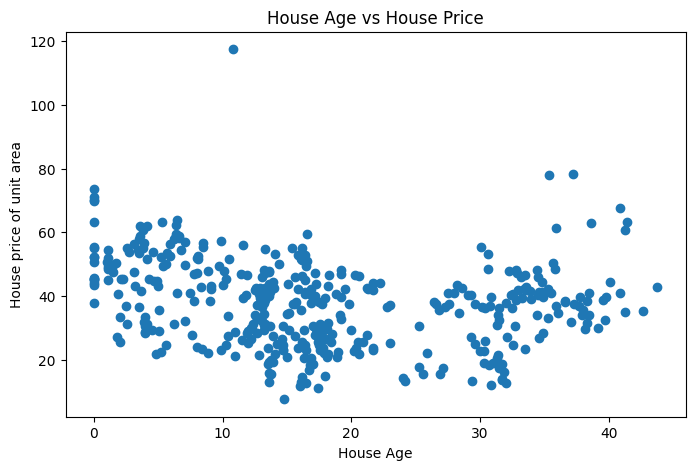

In [48]:
#house age vs house price scatter plot
plt.figure(figsize=(8,5))
plt.scatter(
    df["X2 house age"],
    df["Y house price of unit area"]
)

plt.xlabel("House Age")
plt.ylabel("House price of unit area")
plt.title("House Age vs House Price")

plt.show()

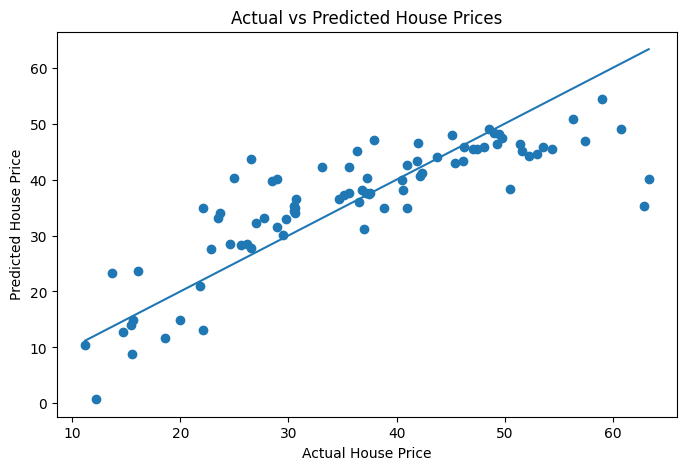

In [49]:
#Actual vs predicted value
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title("Actual vs Predicted House Prices")

plt.show()



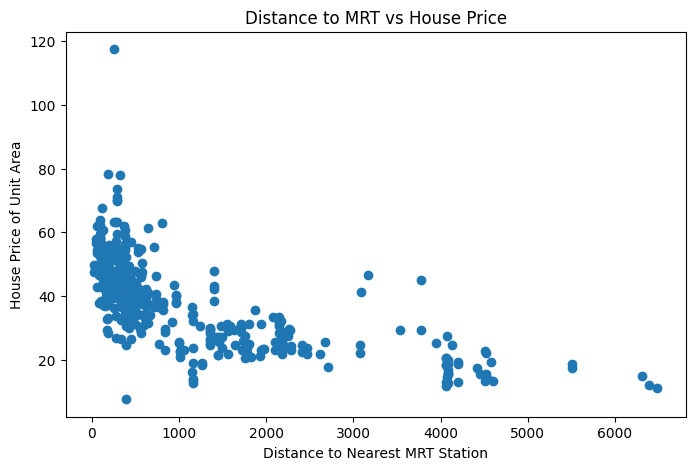

In [50]:
# Distance to MRT vs House Price
plt.figure(figsize=(8,5))

plt.scatter(
    df["X3 distance to the nearest MRT station"],
    df["Y house price of unit area"]
)

plt.xlabel("Distance to Nearest MRT Station")
plt.ylabel("House Price of Unit Area")
plt.title("Distance to MRT vs House Price")

plt.show()

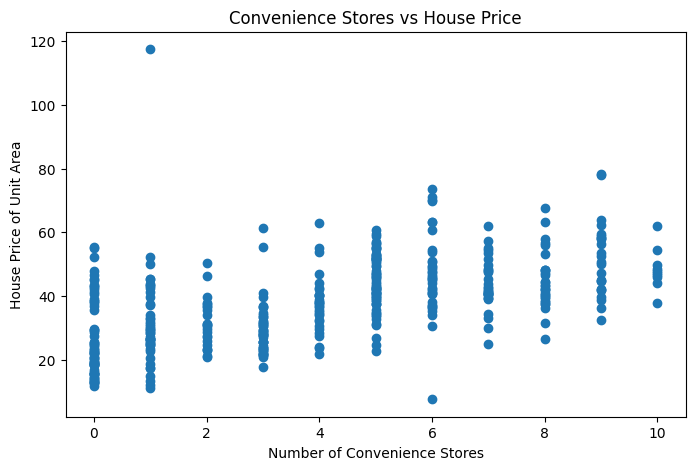

In [51]:
# Convenience Stores vs House Price
plt.figure(figsize=(8,5))

plt.scatter(
    df["X4 number of convenience stores"],
    df["Y house price of unit area"]
)

plt.xlabel("Number of Convenience Stores")
plt.ylabel("House Price of Unit Area")
plt.title("Convenience Stores vs House Price")

plt.show()

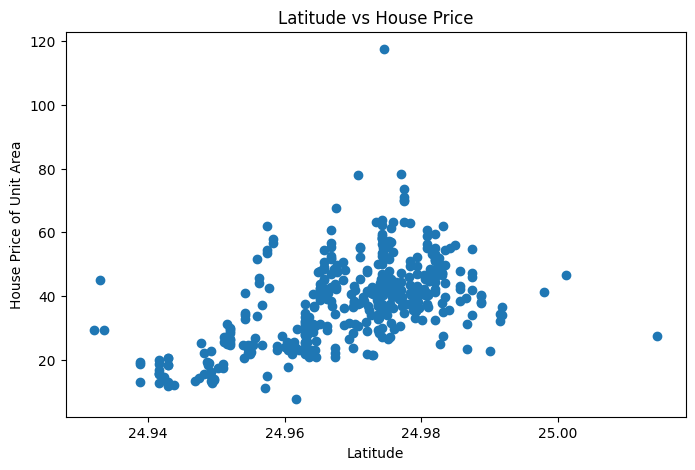

In [52]:
# Latitude vs House Price
plt.figure(figsize=(8,5))

plt.scatter(
    df["X5 latitude"],
    df["Y house price of unit area"]
)

plt.xlabel("Latitude")
plt.ylabel("House Price of Unit Area")
plt.title("Latitude vs House Price")

plt.show()

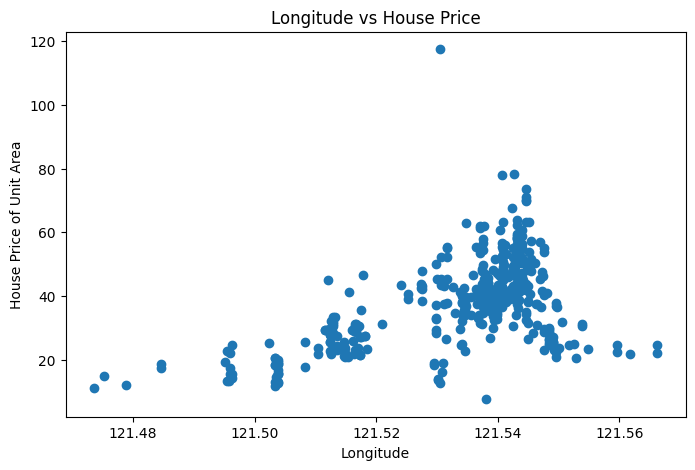

In [53]:
# Longitude vs House Price
plt.figure(figsize=(8,5))

plt.scatter(
    df["X6 longitude"],
    df["Y house price of unit area"]
)

plt.xlabel("Longitude")
plt.ylabel("House Price of Unit Area")
plt.title("Longitude vs House Price")

plt.show()

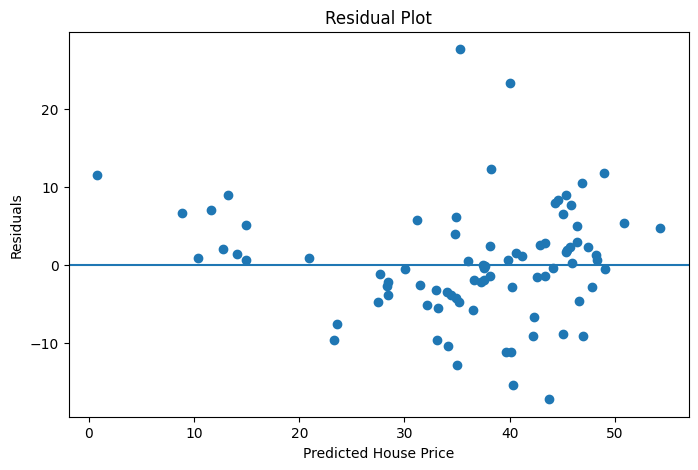

In [54]:
# Residual Plot

residuals = y_test - y_pred

plt.figure(figsize=(8, 5))

plt.scatter(y_pred, residuals)

plt.axhline(y=0)

plt.xlabel("Predicted House Price")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()